In [27]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
## Download Stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
## Load Dataset
df = pd.read_csv('/content/IMDB Dataset.csv.zip')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
## Checking Dataset Information
# Dataset information
df.info()
# checking missing values
# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,0
review,0
sentiment,0


In [25]:
## Text Preprocessing
ps = PorterStemmer()

def clean_text(text):

    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    text = text.split()
    text = [
        ps.stem(word)
        for word in text
        if word not in stopwords.words('english')
    ]
    text = ' '.join(text)
    return text

In [30]:
## Applying preprocessing
df['clean_review'] = df['review'].apply(clean_text)


In [29]:
## display processed data
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,positive,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,positive,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,negative,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visual stun film...


In [31]:
## Encode Sentiment Labels
# Convert positive -> 1
# Convert negative -> 0

df['sentiment'] = df['sentiment'].map({ 'positive': 1,'negative': 0})

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,1,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,1,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visual stun film...


In [32]:
## Feature Extraction using TF-IDF
# TF-IDF Vectorization

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()

y = df['sentiment']

In [33]:
## Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42 )

In [34]:
## Model Training
# Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [35]:
## Prediction
y_pred = model.predict(X_test)

In [36]:
## Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.8862


In [37]:
## Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



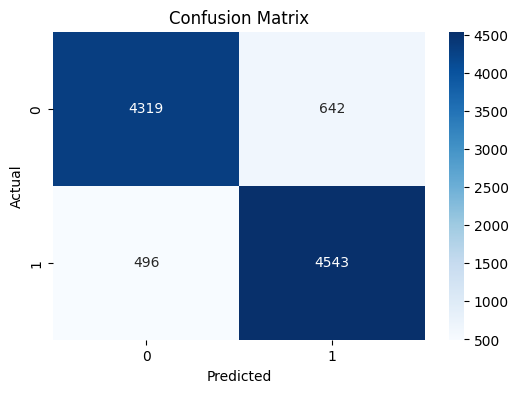

In [38]:
## Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap( cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
## User Input Prediction
sample_review = input("Enter Movie Review: ")

sample_clean = clean_text(sample_review)

sample_vector = tfidf.transform([sample_clean]).toarray()

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Positive Review 😊")
else:
    print("Negative Review 😔")

Enter Movie Review: This movie was amazing and the acting was fantastic.
Positive Review 😊


In [41]:
## PROJECT SUCCESSFULLY COMPLETED...